<a href="https://colab.research.google.com/github/saadbinather/GNN-based-LLM-Halucination-Detection/blob/main/Graph_Augmented_Hallucination_Detection_in_LLMs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

small graph example: GNN implementation

In [16]:
import numpy as np

# 1. SETUP DATA
# Features (X): 3 nodes, 2 features each [Age, Income_Level]
# Node 0 (Ali), Node 1 (Sara), Node 2 (Zain)
X = np.array([
    [1, 0],  # Ali
    [0, 1],  # Sara
    [1, 1]   # Zain
])

# Adjacency Matrix (A): Ali is friends with Sara and Zain
A = np.array([
    [0, 1, 1],
    [1, 0, 0],
    [1, 0, 0]
])

print("--- Step 1: Initial Features ---")
print(X)

# 2. ADD SELF-LOOPS (A_hat = A + I)
# This ensures Ali doesn't forget his own features during aggregation
I = np.eye(3)
A_hat = A + I

# 3. COMPUTE DEGREE MATRIX (D)
# Degree is the sum of each row (number of connections)
degrees = np.sum(A_hat, axis=1)
D_hat = np.diag(degrees)

# 4. NORMALIZATION (Inverse of D * A_hat)
# Simple Row-Normalization: Every neighbor gets an equal share of "voice"
D_inv = np.linalg.inv(D_hat)
A_norm = D_inv @ A_hat

print("\n--- Step 4: Normalized Adjacency (The Kernel) ---")
print(A_norm)

# 5. AGGREGATION (A_norm * X)
# This is where the 'gossip' happens
aggregated_features = A_norm @ X

print("\n--- Step 5: Aggregated Features (Neighborhood Info) ---")
print(aggregated_features)

# 6. LEARNABLE WEIGHTS (W)
# Let's say we want to output 3 hidden features instead of 2
W = np.array([
    [0.5, 0.1],
    [0.2, 0.9]
])

# 7. FINAL LAYER OUTPUT (Agg * W + ReLU)
Z = aggregated_features @ W
H = np.maximum(0, Z)  # ReLU Activation

print("\n--- Step 7: Final GNN Layer Output (H) ---")
print(H)

--- Step 1: Initial Features ---
[[1 0]
 [0 1]
 [1 1]]

--- Step 4: Normalized Adjacency (The Kernel) ---
[[0.33333333 0.33333333 0.33333333]
 [0.5        0.5        0.        ]
 [0.5        0.         0.5       ]]

--- Step 5: Aggregated Features (Neighborhood Info) ---
[[0.66666667 0.66666667]
 [0.5        0.5       ]
 [1.         0.5       ]]

--- Step 7: Final GNN Layer Output (H) ---
[[0.46666667 0.66666667]
 [0.35       0.5       ]
 [0.6        0.55      ]]


Built-in GNN

In [17]:
!pip install torch_geometric
import torch
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
import torch.nn.functional as F

# 1. Data
# Features (x): [Has Laptop (1/0), Likes Coffee (1/0)]
x = torch.tensor([[1, 1], [1, 0], [0, 1], [0, 0]], dtype=torch.float)

# Connections (edge_index):
# [0, 1] means node0 and node1 are friends
edge_index = torch.tensor([[0, 1, 1, 2, 2, 3],
                           [1, 0, 2, 1, 3, 2]], dtype=torch.long)

# Labels (y): 1 = Programmer, 0 = Not Programmer
y = torch.tensor([1, 1, 0, 0], dtype=torch.long)

data = Data(x=x, edge_index=edge_index, y=y)

# 2. Simple GNN Model Banayein
class SimpleGNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        # GCN (Graph Convolutional Network) layer
        self.conv1 = GCNConv(2, 4) # Input features 2, Hidden units 4
        self.conv2 = GCNConv(4, 2) # Output 2 classes (Yes/No)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        # Pehli layer + Activation
        x = self.conv1(x, edge_index)
        x = F.relu(x)

        # Doosri layer
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# Model initialize karein
model = SimpleGNN()
print(model)

# Forward pass: Get predictions for all 4 nodes
out = model(data)
print(out.exp()) # Using .exp() converts logs back to 0-1 probabilities

SimpleGNN(
  (conv1): GCNConv(2, 4)
  (conv2): GCNConv(4, 2)
)
tensor([[0.5290, 0.4710],
        [0.5305, 0.4695],
        [0.5152, 0.4848],
        [0.5000, 0.5000]], grad_fn=<ExpBackward0>)


Halueval data fetching

In [18]:
import requests
import json

# The 'raw' version of the GitHub URL is required for direct downloading
url = "https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/dialogue_data.json"

def fetch_halueval_dialogue():
    print("Fetching data... this might take a moment due to file size.")
    response = requests.get(url)

    if response.status_code == 200:
        # The file is a 'JSON Lines' format (one JSON object per line)
        # We split by lines and parse each one
        data = [json.loads(line) for line in response.text.strip().split('\n')]
        print(f"Successfully fetched {len(data)} samples.")
        return data
    else:
        print(f"Failed to fetch data. Status code: {response.status_code}")
        return None

# Execute
dialogue_data = fetch_halueval_dialogue()

# Example: Peek at the first sample
if dialogue_data:
    print("\nSample Data Structure:")
    print(json.dumps(dialogue_data[0], indent=2))









Fetching data... this might take a moment due to file size.
Successfully fetched 10000 samples.

Sample Data Structure:
{
  "knowledge": "Iron Man is starring Robert Downey Jr.Robert Downey Jr. starred in Zodiac (Crime Fiction Film)Zodiac (Crime Fiction Film) is starring Jake Gyllenhaal",
  "dialogue_history": "[Human]: Do you like Iron Man [Assistant]: Sure do! Robert Downey Jr. is a favorite. [Human]: Yes i like him too did you know he also was in Zodiac a crime fiction film. ",
  "right_response": "I like crime fiction! Didn't know RDJ was in there. Jake Gyllenhaal starred as well.",
  "hallucinated_response": "I'm not a fan of crime movies, but I did know that RDJ starred in Zodiac with Tom Hanks."
}


In [19]:
(dialogue_data[0])

{'knowledge': 'Iron Man is starring Robert Downey Jr.Robert Downey Jr. starred in Zodiac (Crime Fiction Film)Zodiac (Crime Fiction Film) is starring Jake Gyllenhaal',
 'dialogue_history': '[Human]: Do you like Iron Man [Assistant]: Sure do! Robert Downey Jr. is a favorite. [Human]: Yes i like him too did you know he also was in Zodiac a crime fiction film. ',
 'right_response': "I like crime fiction! Didn't know RDJ was in there. Jake Gyllenhaal starred as well.",
 'hallucinated_response': "I'm not a fan of crime movies, but I did know that RDJ starred in Zodiac with Tom Hanks."}

In [20]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 51.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [21]:
import requests
import spacy

nlp = spacy.load("en_core_web_sm")

# --- WIKIDATA GROUNDING FUNCTION ---
def check_wikidata(subj, obj):
    """Wikidata se check karta hai ke kya in do entities ka koi rishta hai."""
    url = 'https://query.wikidata.org/sparql'
    # Yeh query check karti hai ke kya Subj aur Obj ke darmiyan koi bhi direct property exist karti hai
    query = f"""
    SELECT ?property WHERE {{
      ?s ?p ?o .
      ?s rdfs:label "{subj}"@en .
      ?o rdfs:label "{obj}"@en .
      SERVICE wikibase:label {{ bd:serviceParam wikibase:language "en". }}
    }} LIMIT 1
    """
    try:
        r = requests.get(url, params={'format': 'json', 'query': query}, timeout=2)
        data = r.json()
        # Agar results mein kuch aya, matlab relation exist karta hai
        return 1 if len(data['results']['bindings']) > 0 else 0
    except:
        return 0 # Timeout ya error ki surat mein 0


def get_cooccurrence_edges(text):
    doc = nlp(text)
    co_edges = []

    for sent in doc.sents:
        ents = [ent.text for ent in sent.ents if len(ent.text) > 2]

        for i in range(len(ents)):
            for j in range(i+1, len(ents)):
                co_edges.append((ents[i], "co_occurs", ents[j]))

    return co_edges

def NER(text):
    doc = nlp(text)

    # -------- ENTITY EXTRACTION --------
    entities = list(set([ent.text.strip() for ent in doc.ents if len(ent.text.strip()) > 2]))


    # -------- RELATION EXTRACTION --------
    relations = []

    for sent in doc.sents:
        for token in sent:

            if token.pos_ == "VERB":
                subj = None
                obj = None

                # SUBJECT
                for child in token.children:
                    if child.dep_ in ("nsubj", "nsubjpass"):
                        subj = " ".join([w.text for w in child.subtree])

                # OBJECT
                for child in token.children:
                    if child.dep_ in ("dobj", "attr", "pobj"):
                        obj = " ".join([w.text for w in child.subtree])

                if subj and obj:
                    relations.append((subj.strip(), token.lemma_, obj.strip()))

    return entities, relations
#-------------------------------MAIN LOOP--------------------------------------

graphs = []

# ------------------------------- MAIN LOOP --------------------------------------

graphs = []

# Pehle 100-200 samples se start karo testing ke liye, kyunke API time legi
for i in range(100):
    sample = dialogue_data[i]

    knowledge = sample["knowledge"]
    dialogue = sample["dialogue_history"]
    right_resp = sample["right_response"]
    hallu_resp = sample["hallucinated_response"]

    # Scenarios list taake code repeat na ho (Sample A aur B ke liye)
    scenarios = [
        {"text": knowledge + " " + dialogue + " " + right_resp, "label": 0},
        {"text": knowledge + " " + dialogue + " " + hallu_resp, "label": 1}
    ]

    for sc in scenarios:
        entities, relations = NER(sc["text"])
        co_edges = get_cooccurrence_edges(sc["text"])

        final_relations = []

        # 1. Semantic Relations ko Wikidata se check karo
        for rel in relations:
            subj, action, obj = rel
            support = check_wikidata(subj, obj) # Yahan function call ho raha hai
            final_relations.append({
                "triple": rel,
                "type": "semantic",
                "kg_support": support
            })

        # 2. Co-occurrence edges add karo (Inka KG support default 1 rakhtay hain ya skip)
        for co in co_edges:
            final_relations.append({
                "triple": co,
                "type": "co-occurrence",
                "kg_support": 1 # Co-occurrence usually context factual hi hota hai
            })

        graphs.append({
            "entities": entities,
            "relations": final_relations,
            "label": sc["label"]
        })

    if i % 10 == 0:
        print(f"✅ Processed {i} samples...")




✅ Processed 0 samples...
✅ Processed 10 samples...
✅ Processed 20 samples...
✅ Processed 30 samples...
✅ Processed 40 samples...
✅ Processed 50 samples...
✅ Processed 60 samples...
✅ Processed 70 samples...
✅ Processed 80 samples...
✅ Processed 90 samples...


In [25]:
graphs[92]

{'entities': ['The Boy in',
  'Pyjamas Historical',
  'John Boynes',
  'Pyjamas',
  'John Boyne'],
 'relations': [{'triple': ('John Boyne',
    'write',
    'The Boy in the Striped PyjamasThe Boy in the Striped Pyjamas'),
   'type': 'semantic',
   'kg_support': 0},
  {'triple': ('I', 'like', 'John Boynes books'),
   'type': 'semantic',
   'kg_support': 0},
  {'triple': ('you', 'recommend', 'any other books'),
   'type': 'semantic',
   'kg_support': 0},
  {'triple': ('you', 'enjoy', 'its a tragicomedy'),
   'type': 'semantic',
   'kg_support': 0},
  {'triple': ('I', 'help', 'you'), 'type': 'semantic', 'kg_support': 0},
  {'triple': ('John Boyne', 'co_occurs', 'The Boy in'),
   'type': 'co-occurrence',
   'kg_support': 1},
  {'triple': ('John Boyne', 'co_occurs', 'Pyjamas'),
   'type': 'co-occurrence',
   'kg_support': 1},
  {'triple': ('John Boyne', 'co_occurs', 'John Boynes'),
   'type': 'co-occurrence',
   'kg_support': 1},
  {'triple': ('The Boy in', 'co_occurs', 'Pyjamas'),
   'type

/tmp/ipykernel_2606/3876961025.py:43: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2606/3876961025.py:43: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


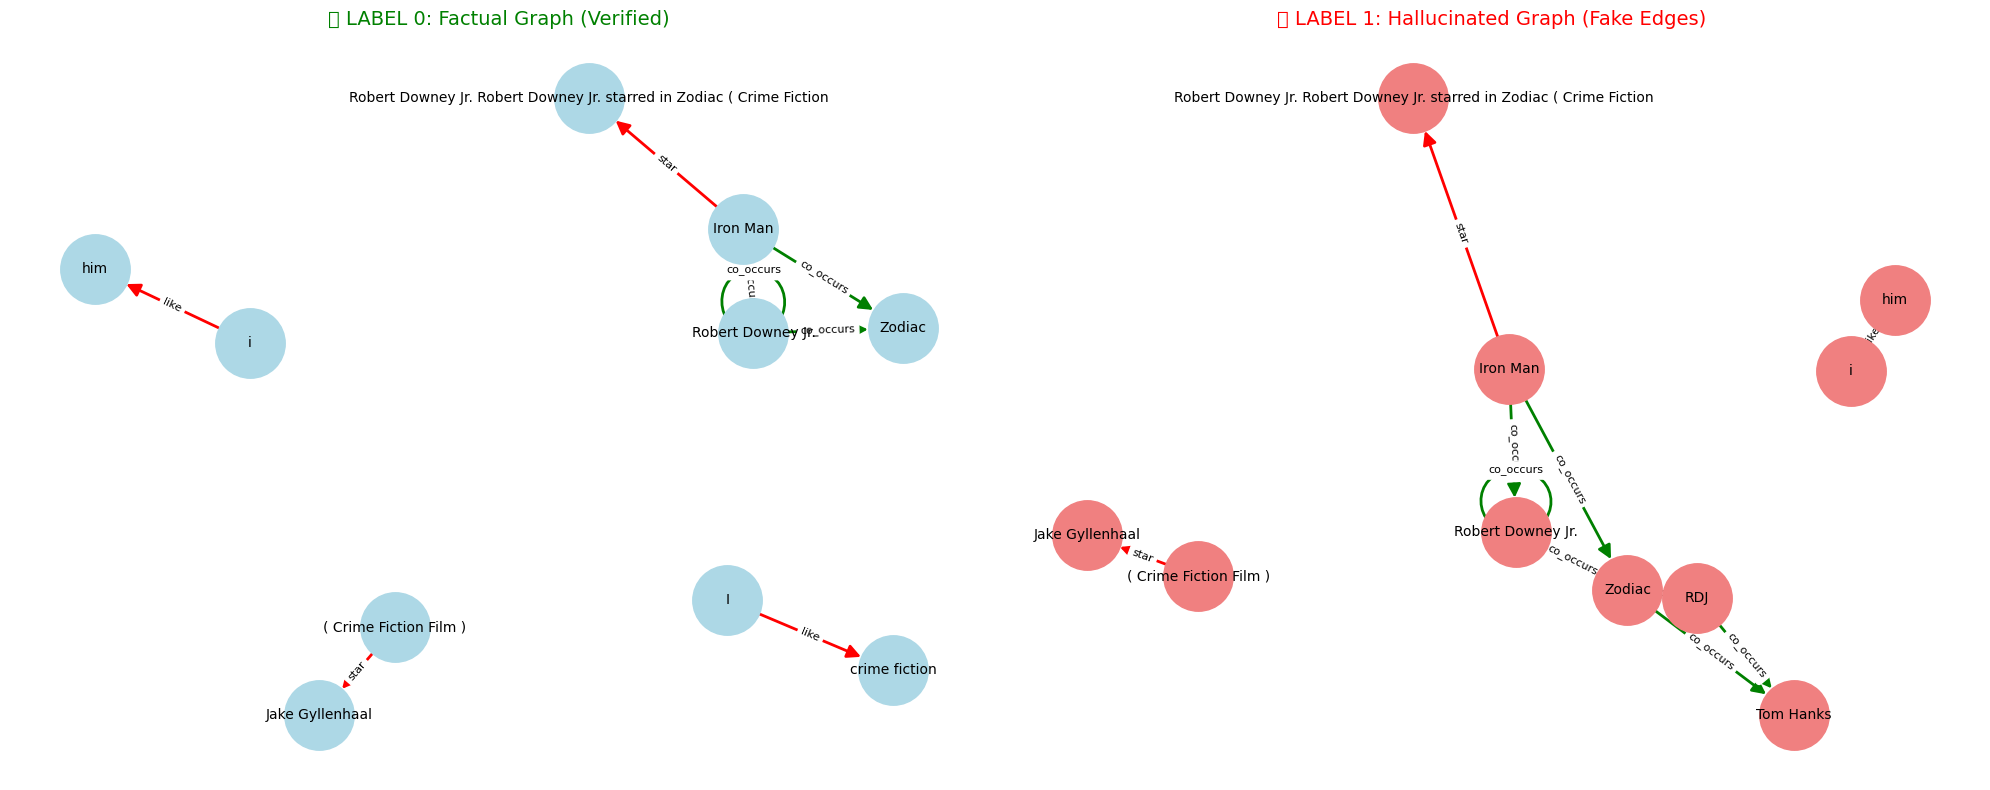

In [26]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_comparison(graph_0, graph_1):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    # --- 1. Label 0 (Factual Graph) Visualization ---
    G0 = nx.DiGraph()
    for rel in graph_0['relations']:
        subj, action, obj = rel['triple']
        # Color logic: KG Support 1 = Green, 0 = Red
        color = 'green' if rel['kg_support'] == 1 else 'red'
        G0.add_edge(subj, obj, label=action, color=color)

    pos0 = nx.spring_layout(G0, k=0.5)
    edge_colors0 = [G0[u][v]['color'] for u, v in G0.edges()]

    nx.draw(G0, pos0, ax=ax1, with_labels=True, node_color='lightblue',
            node_size=2500, font_size=10, edge_color=edge_colors0, width=2, arrowsize=20)

    edge_labels0 = nx.get_edge_attributes(G0, 'label')
    nx.draw_networkx_edge_labels(G0, pos0, edge_labels=edge_labels0, ax=ax1, font_size=8)
    ax1.set_title("✅ LABEL 0: Factual Graph (Verified)", fontsize=14, color='green')

    # --- 2. Label 1 (Hallucinated Graph) Visualization ---
    G1 = nx.DiGraph()
    for rel in graph_1['relations']:
        subj, action, obj = rel['triple']
        # Color logic
        color = 'green' if rel['kg_support'] == 1 else 'red'
        G1.add_edge(subj, obj, label=action, color=color)

    pos1 = nx.spring_layout(G1, k=0.5)
    edge_colors1 = [G1[u][v]['color'] for u, v in G1.edges()]

    nx.draw(G1, pos1, ax=ax2, with_labels=True, node_color='lightcoral',
            node_size=2500, font_size=10, edge_color=edge_colors1, width=2, arrowsize=20)

    edge_labels1 = nx.get_edge_attributes(G1, 'label')
    nx.draw_networkx_edge_labels(G1, pos1, edge_labels=edge_labels1, ax=ax2, font_size=8)
    ax2.set_title("❌ LABEL 1: Hallucinated Graph (Fake Edges)", fontsize=14, color='red')

    plt.tight_layout()
    plt.show()

# --- Visualization Call ---
# Assume graphs[0] is Label 0 and graphs[1] is Label 1
if len(graphs) >= 2:
    visualize_comparison(graphs[0], graphs[1])

In [27]:
!pip install torch-geometric sentence-transformers -q

import torch
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import RGCNConv, global_mean_pool
from sentence_transformers import SentenceTransformer
import numpy as np

# Load SBERT for Node Embeddings
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [28]:
def prepare_pyg_data(graphs_list):
    pyg_dataset = []

    for g in graphs_list:
        # 1. Node Embeddings (x)
        # Har entity ka text embedding nikaalo
        node_texts = g['entities']
        if not node_texts: continue # Skip empty graphs

        node_x = embedding_model.encode(node_texts)
        x = torch.tensor(node_x, dtype=torch.float)

        # Mapping names to indices
        node_map = {name: i for i, name in enumerate(node_texts)}

        # 2. Edges and Edge Types (edge_index & edge_type)
        edge_index = []
        edge_type = []
        edge_attr = [] # KG Support feature

        # Mapping types to integers
        type_map = {"semantic": 0, "co-occurrence": 1}

        for rel in g['relations']:
            subj, action, obj = rel['triple']
            if subj in node_map and obj in node_map:
                edge_index.append([node_map[subj], node_map[obj]])
                edge_type.append(type_map.get(rel['type'], 1))
                edge_attr.append([rel['kg_support']])

        if not edge_index: continue

        # Convert to Tensors
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_type = torch.tensor(edge_type, dtype=torch.long)
        edge_attr = torch.tensor(edge_attr, dtype=torch.float)
        y = torch.tensor([g['label']], dtype=torch.long)

        # Construct Data object
        data = Data(x=x, edge_index=edge_index, edge_type=edge_type, edge_attr=edge_attr, y=y)
        pyg_dataset.append(data)

    return pyg_dataset

# Convert entire dataset
train_data = prepare_pyg_data(graphs)
print(f"✅ Total PyG graphs ready: {len(train_data)}")

✅ Total PyG graphs ready: 189


In [29]:
class HaluDetectorGNN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, num_relations):
        super(HaluDetectorGNN, self).__init__()
        # R-GCN layers help understand the 'relation' types (semantic vs co-occurs)
        self.conv1 = RGCNConv(input_dim, hidden_dim, num_relations)
        self.conv2 = RGCNConv(hidden_dim, hidden_dim, num_relations)
        self.classifier = torch.nn.Linear(hidden_dim, 2) # Binary: 0 or 1

    def forward(self, data):
        x, edge_index, edge_type, batch = data.x, data.edge_index, data.edge_type, data.batch

        # 1. Message Passing
        x = self.conv1(x, edge_index, edge_type)
        x = F.relu(x)
        x = self.conv2(x, edge_index, edge_type)

        # 2. Global Pooling (Pure graph representation)
        x = global_mean_pool(x, batch)

        # 3. Final Classification
        return self.classifier(x)

# Initialize
model = HaluDetectorGNN(input_dim=384, hidden_dim=64, num_relations=2)

In [30]:
from torch_geometric.loader import DataLoader
import torch.optim as optim

# 1. Hyperparameters
BATCH_SIZE = 32
LEARNING_RATE = 0.01
EPOCHS = 50

# 2. Prepare DataLoader (Data ko batches mein tor deta hai taake RAM crash na ho)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)

# 3. Optimizer aur Loss Function
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = torch.nn.CrossEntropyLoss()

print(f"🚀 Training started on {len(train_data)} graphs...")

model.train()
for epoch in range(1, EPOCHS + 1):
    total_loss = 0
    correct = 0

    for data in train_loader:
        optimizer.zero_grad()           # Purane gradients saaf karo
        out = model(data)               # Forward Pass (Model ka andaza)
        loss = criterion(out, data.y)   # Ghalti (Loss) calculate karo
        loss.backward()                 # Backward Pass (Ghalti se seekho)
        optimizer.step()                # Weights update karo

        total_loss += loss.item()

        # Accuracy calculate karo
        pred = out.argmax(dim=1)
        correct += int((pred == data.y).sum())

    avg_loss = total_loss / len(train_loader)
    acc = correct / len(train_data)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Loss: {avg_loss:.4f} | Accuracy: {acc:.2%}")

print("\n✅ Training Complete!")

🚀 Training started on 189 graphs...
Epoch 001 | Loss: 0.7132 | Accuracy: 43.92%
Epoch 005 | Loss: 0.6950 | Accuracy: 46.56%
Epoch 010 | Loss: 0.6800 | Accuracy: 60.85%
Epoch 015 | Loss: 0.6505 | Accuracy: 55.56%
Epoch 020 | Loss: 0.4960 | Accuracy: 72.49%
Epoch 025 | Loss: 0.3130 | Accuracy: 83.07%
Epoch 030 | Loss: 0.2514 | Accuracy: 87.30%
Epoch 035 | Loss: 0.1821 | Accuracy: 90.48%
Epoch 040 | Loss: 0.1775 | Accuracy: 89.42%
Epoch 045 | Loss: 0.1655 | Accuracy: 89.95%
Epoch 050 | Loss: 0.1558 | Accuracy: 91.01%

✅ Training Complete!


TEST RUN

In [ ]:
# ------------------------------- TESTING ON [990:] -------------------------------

print("🔍 Starting Evaluation on unseen data (Samples 990 to end)...")

test_graphs = []
# 1. Unseen data ko uthao
test_samples = dialogue_data[990:]

for i, sample in enumerate(test_samples):
    # Dono scenarios test karenge taake accuracy fair ho
    for resp_key, label in [("right_response", 0), ("hallucinated_response", 1)]:
        try:
            text = f"{sample['knowledge']} {sample['dialogue_history']} {sample[resp_key]}"

            # Wahi NER, Co-occurrence aur Wikidata call jo pehle ki thi
            entities, relations = NER(text)
            co_edges = get_cooccurrence_edges(text)

            final_rels = []
            # Sirf top 10 check karlo speed ke liye
            for rel in (relations + co_edges)[:10]:
                subj, action, obj = rel
                support = check_wikidata(subj, obj)
                final_rels.append({
                    "triple": rel,
                    "type": "semantic" if rel in relations else "co-occurrence",
                    "kg_support": support
                })

            test_graphs.append({
                "entities": entities,
                "relations": final_rels,
                "label": label
            })
        except:
            continue

# 2. PyG format mein convert karo (Prepare embeddings)
test_pyg_data = prepare_pyg_data(test_graphs)
test_loader = DataLoader(test_pyg_data, batch_size=1, shuffle=False)

# 3. Model Prediction Loop
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for data in test_loader:
        out = model(data)
        pred = out.argmax(dim=1).item()
        all_preds.append(pred)
        all_labels.append(data.y.item())

# 4. Accuracy Calculation
from sklearn.metrics import accuracy_score, classification_report

acc = accuracy_score(all_labels, all_preds)
print(f"\n🎯 Test Results on Unseen Data:")
print(f"Total Test Samples: {len(all_labels)}")
print(f"Overall Accuracy: {acc:.2%}")
print("\nDetailed Report:")
print(classification_report(all_labels, all_preds, target_names=['Factual (0)', 'Hallucinated (1)']))

🔍 Starting Evaluation on unseen data (Samples 990 to end)...
